In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import linalg as la

from jax.numpy import einsum
from tqdm import tqdm

# for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import (
    paper_style,
    paper_style_small,
    revtex_textwidth,
    revtex_columnwidth,
    set_size,
)
from blochK.observable import conductivity_orbital_resolved

from alter_surf.hamiltonian_CuMnAs import H_3D_fct, H_slab_fct
from alter_surf.hamiltonian_DLKK import (
    create_H_DLKK_3D,
    create_H_DLKK_3D_MF,
    create_H_DLKK_true3D,
)

import plot_funcs as pf

import sys, os


from alter_surf.utils3D import projector2layer

import pickle

matplotlib.rcParams.update(
    {
        "font.size": 7,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.9
aps_halfwidth = 3.4

make the three models

In [3]:
# define the three models
original_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1)

soc_params = [
    original_params,
    original_params | {"lambda1": 0.4},
    original_params | {"lambda2": 0.2},
    original_params | {"lambda3": 0.2},
]

models_2d = [pf.slab_ham({"len_z": 31} | par) for par in soc_params]
models_3d = [
    blochK.Hamiltonian3D(H_3D_fct, param=par, basis=["spin", "z-layer", "sublattice"])
    for par in soc_params
]
[m3.add_operator("spin", np.array([1, 1, 1, 1, -1, -1, -1, -1])) for m3 in models_3d]

[None, None, None, None]

In [4]:
# define spectral path
n_k_2d_path = 100
points = np.array([[0, 1], [0, 0], [1, 0], [0, 1], [1, 1], [0, 0]])
labels = [r"Y", r"$\Gamma$", r"X", r"Y", r"M", r"$\Gamma$"]
path = pf.make_path(points, n_k_2d_path)
path_positions = np.linspace(0, len(path), len(labels)).astype(int)

# define 2d slice k grids
spillover = 0.25
n_k_grid = 101
k_slice = np.linspace(
    -np.pi * (1 + spillover), np.pi * (1 + spillover), n_k_grid, endpoint=False
)
KX_slice, KY_slice = np.meshgrid(k_slice, k_slice)

In [5]:
# solve paths
energies_path = []
states_path = []

for model in tqdm(models_2d):
    energies, states = model.diagonalize(*path.T)
    energies_path.append(energies)
    states_path.append(states)

# solve 2D grids
energies_grid = []
states_grid = []

for model in tqdm(models_2d):
    energies, states = model.diagonalize(KX_slice, KY_slice)
    energies_grid.append(energies)
    states_grid.append(states)

100%|██████████| 4/4 [09:01<00:00, 135.31s/it]


In [6]:
from tqdm import tqdm

# make spectral walk functions
eta = 4e-2

spec_e_vals = []
spec_boundary_path = []
spec_bulk_path = []

for model, states, energies in zip(tqdm(models_2d), states_path, energies_path):

    e_vals = np.linspace(np.min(energies), np.max(energies), 200)
    specs_boundary_walk = pf.make_spectral_functions(
        model, [0], states, energies, e_vals, eta
    )
    specs_bulk_walk = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, e_vals, eta
    )

    colors_bulk_walk, colors_boundary_walk = pf.normalize_and_find_colours(
        specs_bulk_walk, specs_boundary_walk, 0.7
    )
    spec_e_vals.append(e_vals)
    spec_boundary_path.append(colors_boundary_walk)
    spec_bulk_path.append(colors_bulk_walk)

del specs_bulk_walk, specs_boundary_walk

100%|██████████| 4/4 [05:12<00:00, 78.12s/it] 


In [7]:
# make slice spectral functions

fermi_level = np.array([0])
eta = 2e-2

spec_boundary_grid_val = []
spec_bulk_grid_val = []

# find the spectral functions
for model, states, energies in zip(tqdm(models_2d), states_grid, energies_grid):
    specs_boundary_slice = pf.make_spectral_functions(
        model, [0], states, energies, fermi_level, eta
    )
    specs_bulk_slice = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, fermi_level, eta
    )

    spec_boundary_grid_val.append(specs_boundary_slice)
    spec_bulk_grid_val.append(specs_bulk_slice)

spec_boundary_grid_val = np.array(spec_boundary_grid_val)
spec_bulk_grid_val = np.array(spec_bulk_grid_val)

# normalise together
lim_bulk = (np.min(spec_bulk_grid_val[:, 0]), np.max(spec_bulk_grid_val[:, 0]))
lim_boundary = (
    np.min(spec_boundary_grid_val[:, 0]),
    np.max(spec_boundary_grid_val[:, 0]),
)
lim_spin = (
    np.min([spec_bulk_grid_val[:, 1], spec_boundary_grid_val[:, 1]]),
    np.max([spec_bulk_grid_val[:, 1], spec_boundary_grid_val[:, 1]]),
)
lim_spin = np.max(np.abs(lim_spin))


spec_boundary_grid = []
spec_bulk_grid = []
for i in tqdm(range(len(models_2d))):
    colors_bulk_slice, colors_boundary_slice = pf.normalize_and_find_colours(
        spec_bulk_grid_val[i],
        spec_boundary_grid_val[i],
        0.5,
        lim_bulk,
        lim_boundary,
        lim_spin,
    )
    spec_boundary_grid.append(colors_boundary_slice)
    spec_bulk_grid.append(colors_bulk_slice)

del specs_bulk_slice, specs_boundary_slice, spec_boundary_grid_val, spec_bulk_grid_val

100%|██████████| 4/4 [00:00<00:00, 289.29it/s]


In [8]:
# 3d band structures
# make 3d band structures
path_3d = np.array(
    [
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0],
        [0, 1, 0],
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
        [0, 0, 1],
    ]
)
k_walk_3d = (
    np.concatenate(
        [
            np.linspace(path_3d[i], path_3d[i + 1], n_k_2d_path, endpoint=False)
            for i in range(len(path_3d) - 1)
        ]
    )
    * np.pi
)
labels_3d = [r"Y", r"X", r"$\Gamma$", r"Y", r"M", r"R", r"Y", r"Z"]
label_positions_3d = np.linspace(0, len(k_walk_3d), len(labels_3d)).astype(int)

es_3d = []
for model in models_3d:
    e_vals, _ = model.diagonalize(*k_walk_3d.T)
    es_3d.append(e_vals)

del e_vals

In [9]:
# make conductivities
from alter_surf.utils_CuMnAs import get_conductivity_layer_resolved as gcl_drum_weyl


layers = []
conds = []
spin_conds = []

for model in tqdm(models_2d):
    l, c, s = gcl_drum_weyl(model, Lk=50)
    layers.append(l)
    conds.append(c)
    spin_conds.append(s)

del l, c, s

100%|██████████| 4/4 [17:19<00:00, 259.93s/it]


In [10]:
# save everything
all_results = dict(
    models_2d=models_2d,
    models_3d=models_3d,
    #
    labels=labels,
    path=path,
    path_positions=path_positions,
    spec_e_vals=spec_e_vals,
    spec_bulk_path=spec_bulk_path,
    spec_boundary_path=spec_boundary_path,
    #
    spec_bulk_grid=spec_bulk_grid,
    spec_boundary_grid=spec_boundary_grid,
    #
    es_3d=es_3d,
    k_walk_3d=k_walk_3d,
    labels_3d=labels_3d,
    label_positions_3d=label_positions_3d,
    #
    layers=layers,
    conds=conds,
    spin_conds=spin_conds,
)

with open("spin_orbit_drumhead_data.pkl", "wb") as f:
    pickle.dump(all_results, f)

In [11]:
from types import SimpleNamespace

with open("spin_orbit_drumhead_data.pkl", "rb") as f:
    res = pickle.load(f)

r = SimpleNamespace(**res)

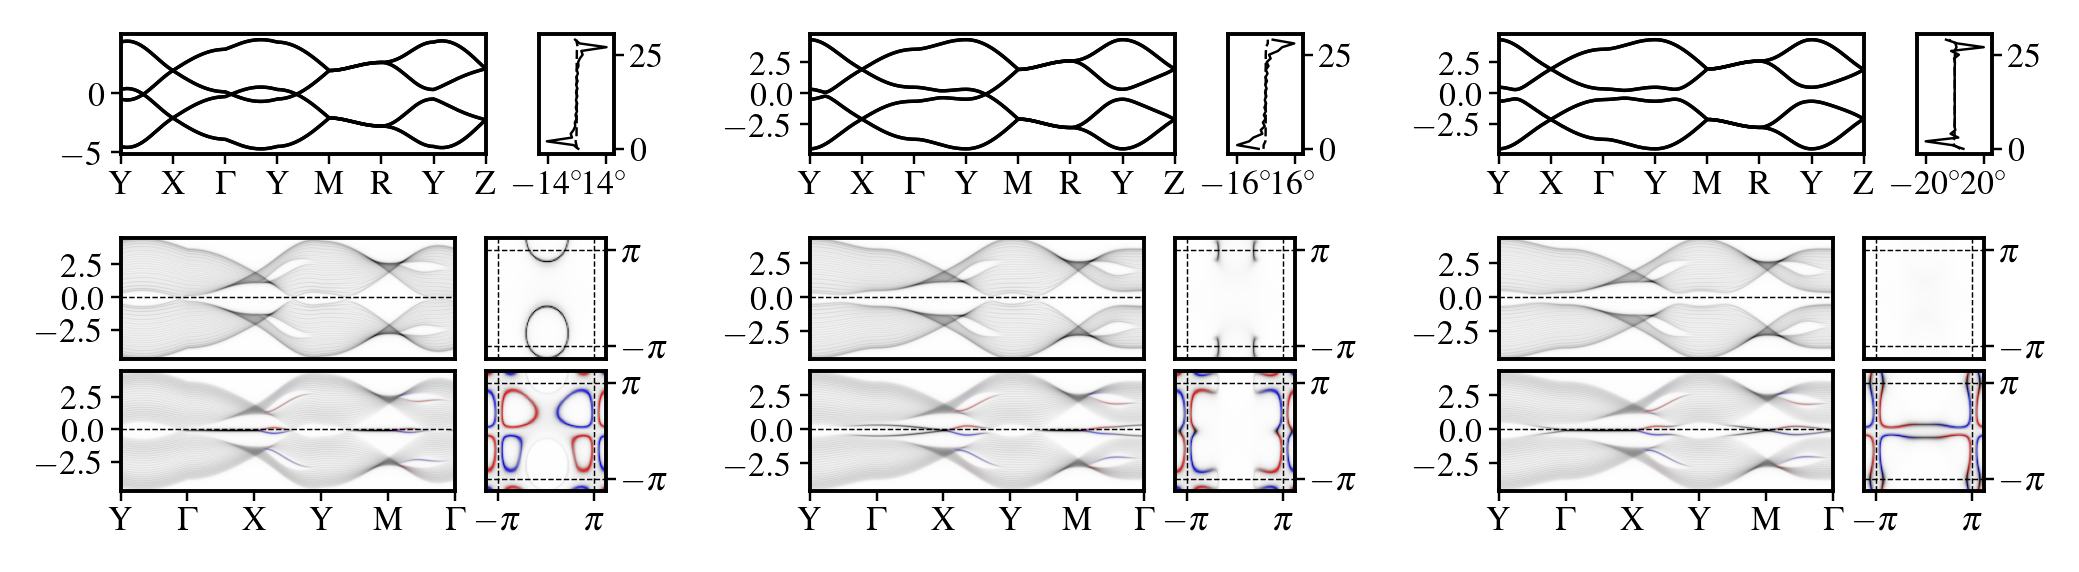

In [12]:
subplot_arrangement = """
aa.b.cc.d.ee.f
..............
ghhh.ijjj.klll
..............
mnnn.oppp.qsss
"""
widths = [4, 0.1, 0.1, 0.9]
h_gap = [1.8]
v_gap1 = 0.7
v_gap2 = 0.1


fig = plt.figure(figsize=(aps_figwidth, aps_figwidth * 2.7 / 11), dpi=350)
axd = fig.subplot_mosaic(
    subplot_arrangement,
    gridspec_kw={"wspace": 0.2, "hspace": 0.0},
    width_ratios=widths + h_gap + widths + h_gap + widths,
    height_ratios=[1, v_gap1, 1, v_gap2, 1],
)

ax_bs = [axd["a"], axd["c"], axd["e"]]
ax_split = [axd["b"], axd["d"], axd["f"]]
ax_bulk_path = [axd["g"], axd["i"], axd["k"]]
ax_bulk_grid = [axd["h"], axd["j"], axd["l"]]
ax_boundary_path = [axd["m"], axd["o"], axd["q"]]
ax_boundary_grid = [axd["n"], axd["p"], axd["s"]]


for i in range(1, 4):

    # 3d band structure
    # ax_bs[i - 1].plot(r.es_3d[0].T, color="grey", lw=0.7)
    ax_bs[i - 1].plot(r.es_3d[i].T, color="k", lw=0.7)
    ax_bs[i - 1].set_xlim(0, len(r.es_3d[i].T))
    ax_bs[i - 1].set_xticks(r.label_positions_3d, r.labels_3d)

    # bulk path
    ax_bulk_path[i - 1].imshow(
        r.spec_bulk_path[i],
        extent=(
            0,
            len(r.path),
            r.spec_e_vals[i][0],
            r.spec_e_vals[i][-1],
        ),
        aspect="auto",
        origin="lower",
    )
    ax_bulk_path[i - 1].tick_params(
        bottom=False,
        labelbottom=False,
    )

    # boundary path
    ax_boundary_path[i - 1].imshow(
        r.spec_boundary_path[i],
        extent=(
            0,
            len(r.path),
            r.spec_e_vals[i][0],
            r.spec_e_vals[i][-1],
        ),
        aspect="auto",
        origin="lower",
    )
    ax_boundary_path[i - 1].set_xticks(r.path_positions, r.labels)

    # bulk grid
    ax_bulk_grid[i - 1].imshow(
        np.swapaxes(r.spec_bulk_grid[i], 0, 1),
        extent=(
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
        ),
    )
    ax_bulk_grid[i - 1].tick_params(
        bottom=False,
        labelbottom=False,
        left=False,
        labelleft=False,
        right=True,
        labelright=True,
    )
    ax_bulk_grid[i - 1].set_xticks([-np.pi, np.pi])
    ax_bulk_grid[i - 1].set_yticks([-np.pi, np.pi])
    ax_bulk_grid[i - 1].set_yticklabels(["$-\\pi$", "$\\pi$"])
    ax_bulk_grid[i - 1].set_xticklabels(["$-\\pi$", "$\\pi$"])

    # boundary grid
    ax_boundary_grid[i - 1].imshow(
        np.swapaxes(r.spec_boundary_grid[i], 0, 1),
        extent=(
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
        ),
    )
    ax_boundary_grid[i - 1].tick_params(
        bottom=True,
        labelbottom=True,
        left=False,
        labelleft=False,
        right=True,
        labelright=True,
    )
    ax_boundary_grid[i - 1].set_xticks([-np.pi, np.pi])
    ax_boundary_grid[i - 1].set_yticks([-np.pi, np.pi])
    ax_boundary_grid[i - 1].set_yticklabels(["$-\\pi$", "$\\pi$"])
    ax_boundary_grid[i - 1].set_xticklabels(["$-\\pi$", "$\\pi$"])

    for a in (ax_boundary_grid[i - 1], ax_bulk_grid[i - 1]):
        a.axhline(-np.pi, color="k", ls="--", lw=0.3)
        a.axhline(np.pi, color="k", ls="--", lw=0.3)
        a.axvline(-np.pi, color="k", ls="--", lw=0.3)
        a.axvline(np.pi, color="k", ls="--", lw=0.3)

    # spin splitter
    l = r.layers[i]
    a = r.spin_conds[i][:, 1, 0]
    b = r.conds[i][:, 0, 0]
    spin_splitter_x = 2 * np.arctan(a / b) * 180 / np.pi
    a = r.spin_conds[i][:, 0, 1]
    b = r.conds[i][:, 1, 1]
    spin_splitter_y = 2 * np.arctan(a / b) * 180 / np.pi

    ax_split[i - 1].plot(spin_splitter_x, l, markersize=1, linewidth=0.5, color="k")
    ax_split[i - 1].plot(
        spin_splitter_y,
        l,
        markersize=1,
        linewidth=0.5,
        color="k",
        linestyle="--",
    )
    ax_split[i - 1].tick_params(
        left=False,
        labelleft=False,
        right=True,
        labelright=True,
    )

    max_split = int(np.round(np.max([spin_splitter_x, spin_splitter_y])))
    ax_split[i - 1].set_xticks([-max_split, max_split])
    ax_split[i - 1].set_xticklabels([f"$-{max_split}^\\circ$", f"${max_split}^\\circ$"])

    ax_split[i - 1].set_xlim(-1.3 * max_split, 1.3 * max_split)
    ax_split[i - 1].set_xlim(-1.3 * max_split, 1.3 * max_split)

for a in axd:
    axd[a].tick_params(length=2, width=0.5, pad=1.3)

for a in (axd["g"], axd["m"], axd["i"], axd["o"], axd["k"], axd["q"]):
    a.axhline(0, color="k", ls="--", lw=0.3)

plt.savefig("spin_orbit_drumhead.png", dpi=350, bbox_inches="tight", transparent=True)

In [13]:
# fix the normalisation